In [1]:
import os, importlib
from getpass import getpass
from openai import OpenAI
os.environ.setdefault("OPENAI_API_KEY", "placeholder-not-used")
import Likelihoods, LLMs_routines
importlib.reload(Likelihoods)
importlib.reload(LLMs_routines)
from Likelihoods import *              
MODEL = "openai/gpt-oss-120b"
GROQ_KEY = os.environ.get("GROQ_API_KEY") or getpass("Groq API key: ").strip()
assert GROQ_KEY.startswith("gsk_"), f"this does not look like a Groq key: {GROQ_KEY[:8]!r}"
LLMs_routines.client = OpenAI(api_key=GROQ_KEY, base_url="https://api.groq.com/openai/v1")
LLMs_routines.MODEL_NAME = MODEL
print("model    :", LLMs_routines.MODEL_NAME)
print("endpoint :", LLMs_routines.client.base_url)

model    : openai/gpt-oss-120b
endpoint : https://api.groq.com/openai/v1/


In [6]:
N_RUN = 20                                   # rounds; every round makes 2 LLM calls -> 40 calls
beliefs_init = np.array([np.ones(K) / K, np.ones(K) / K])

np.random.seed(0)
Dyn_close = LLMs_routines.Dynamics_with_by_hand_bayes(beliefs_init[0], beliefs_init[1], Lx_close, Ly_close, N_RUN)
np.save("dynamics_gptoss120b_close.npy", Dyn_close)

print("close setting -- final beliefs   agent 1 (x):", np.round(Dyn_close[-1, 0], 3),
      "  agent 2 (y):", np.round(Dyn_close[-1, 1], 3), "   true state:", LABELS[TRUE])

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-120b` in organization `org_01m2ne2d1zentvy9grsqbgnftr` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 199638, Requested 588. Please try again in 1m37.631999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

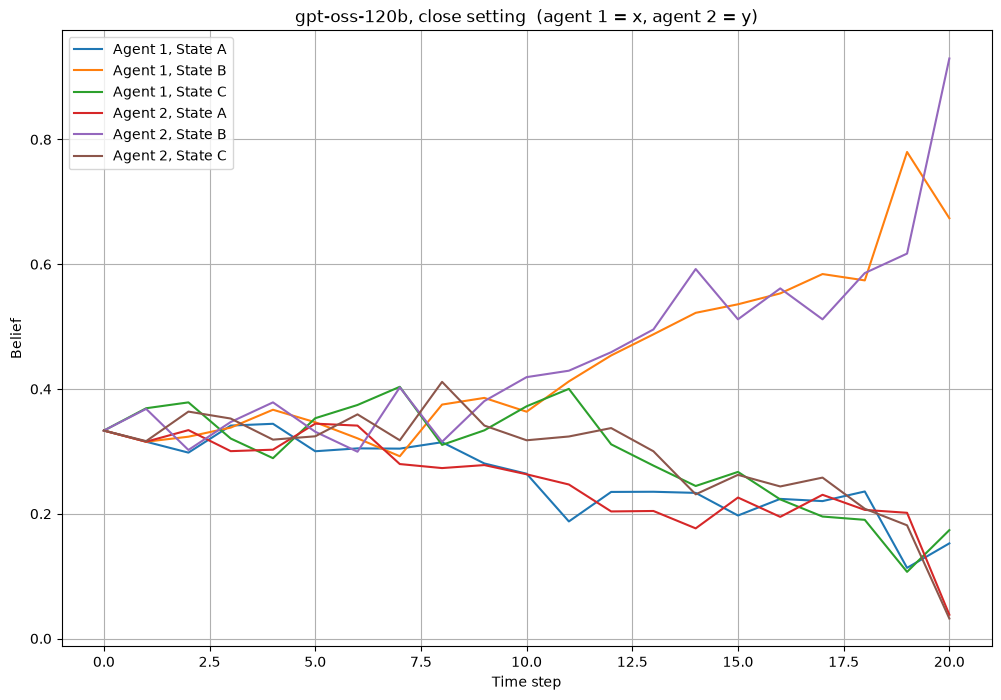

In [5]:
LLMs_routines.plot_Dynamic(Dyn_close, title="gpt-oss-120b, close setting  (agent 1 = x, agent 2 = y)")

In [4]:
N_RUN = 20
beliefs_init = np.array([np.ones(K) / K, np.ones(K) / K])

np.random.seed(0)
Dyn_far = LLMs_routines.Dynamics_with_by_hand_bayes(beliefs_init[0], beliefs_init[1], Lx, Ly, N_RUN)
np.save("dynamics_gptoss120b_far.npy", Dyn_far)

print("far setting -- final beliefs   agent 1 (x):", np.round(Dyn_far[-1, 0], 3),
      "  agent 2 (y):", np.round(Dyn_far[-1, 1], 3), "   true state:", LABELS[TRUE])

far setting -- final beliefs   agent 1 (x): [1. 0. 0.]   agent 2 (y): [1. 0. 0.]    true state: A


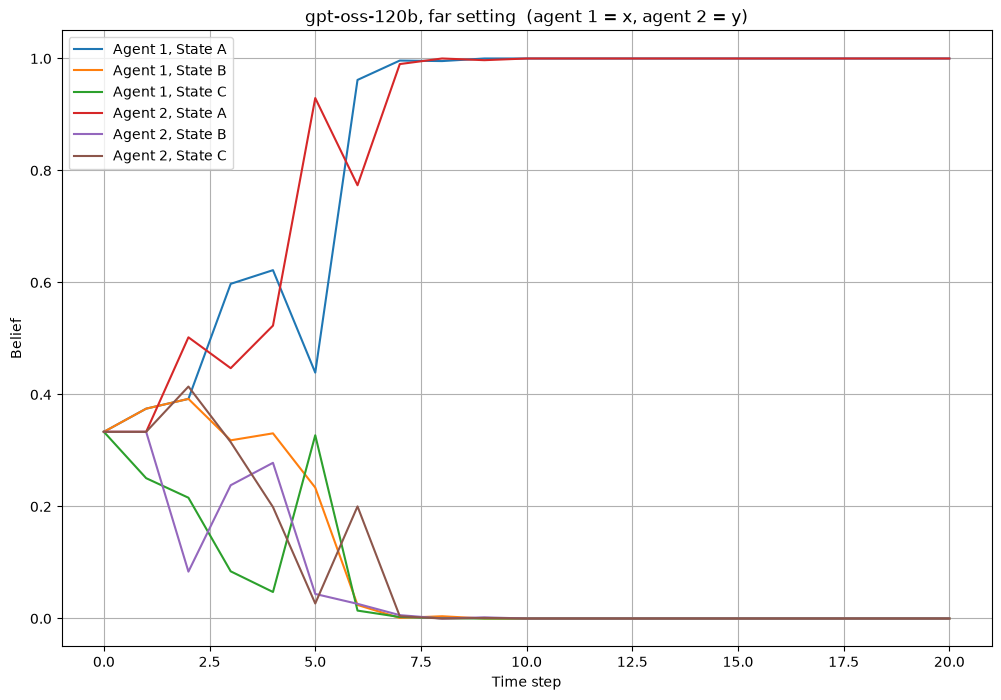

In [5]:
LLMs_routines.plot_Dynamic(Dyn_far, title="gpt-oss-120b, far setting  (agent 1 = x, agent 2 = y)")